# TP 0 — Fondements mathématiques en pratique (NumPy)

> Support théorique : [cours_fondements_maths_python.md](cours_fondements_maths_python.md).

**Objectif.** Transformer en code les intuitions du module 0 : vecteurs et produit scalaire, norme et similarité cosinus, **descente de gradient à la main**, raisonnement de Bayes par simulation, loi des grands nombres, softmax stable et pièges de *broadcasting*.

**Comment travailler.** Lisez chaque cellule, exécutez-la, observez la sortie. Les cellules contiennent des `assert` : si une cellule passe sans erreur, le résultat est conforme à ce qui est annoncé. Un exercice guidé (cellule `TODO` + solution + critère de réussite) clôt le notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Graine reproductible (cf. module 0, §8.4). Fixer la graine facilite le débogage,
# sans garantir une reproductibilité parfaite entre machines/versions.
rng = np.random.default_rng(0)
print("NumPy", np.__version__)

NumPy 2.5.2


## 1. Vecteurs, matrices et produit scalaire

Le **produit scalaire** est la brique d'un neurone et d'une régression linéaire (module 0, §2.2).
On retrouve l'exemple chiffré du cours : poids `w = [0.5, -1.0]`, entrée `x = [2.0, 3.0]`.

In [2]:
w = np.array([0.5, -1.0])
x = np.array([2.0, 3.0])

produit_scalaire = w @ x            # somme pondérée d'un neurone
print("w · x =", produit_scalaire)
assert np.isclose(produit_scalaire, -2.0), "doit valoir (0.5*2) + (-1.0*3) = -2.0"

# Appliquer la même combinaison à toutes les lignes d'un coup : produit matriciel.
X = np.array([[25.0, 32.0],
              [45.0, 65.0],
              [38.0, 48.0]])       # (n=3 observations, d=2 features)
scores = X @ w                     # une valeur par ligne -> forme (3,)
print("formes :", X.shape, "@", w.shape, "->", scores.shape)
assert X.shape == (3, 2) and scores.shape == (3,)
print("scores :", scores)

w · x = -2.0
formes : (3, 2) @ (2,) -> (3,)
scores : [-19.5 -42.5 -29. ]


## 2. Norme, distance et similarité cosinus

La distance euclidienne dépend de l'échelle des variables : c'est la justification du *scaling* (module 1).
La similarité cosinus, elle, ignore les longueurs (utile pour comparer des embeddings, module 4).

In [3]:
alice = np.array([25.0, 30_000.0])   # (âge, salaire)
bob   = np.array([27.0, 35_000.0])

distance = np.linalg.norm(alice - bob)
print("distance euclidienne :", round(distance, 2))
# La composante 'salaire' domine totalement la distance (écart 5000 vs 2).
ecart_age, ecart_salaire = np.abs(alice - bob)
assert ecart_salaire**2 > 1e6 * ecart_age**2, "l'échelle du salaire écrase celle de l'âge"

def cosinus(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

u = np.array([1.0, 2.0, 3.0])
v = np.array([2.0, 4.0, 6.0])         # v = 2u : même direction, norme double
print("cos(u, 2u) =", round(cosinus(u, v), 6))
assert np.isclose(cosinus(u, v), 1.0), "deux vecteurs colinéaires de même sens ont un cosinus de 1"
print("-> le cosinus vaut 1 malgré des normes différentes : il mesure l'angle, pas la longueur.")

distance euclidienne : 5000.0
cos(u, 2u) = 1.0
-> le cosinus vaut 1 malgré des normes différentes : il mesure l'angle, pas la longueur.


## 3. Descente de gradient à la main

On ajuste une droite `y = w·x + b` en suivant le **gradient** de l'erreur quadratique moyenne (MSE),
comme le randonneur qui descend la pente (module 0, §3 ; module 3, §2). On part de données bruitées
générées selon la vraie relation `y = 2x + 1`.

In [4]:
n = 200
x_data = rng.uniform(0, 5, size=n)
bruit = rng.normal(0, 0.5, size=n)
y_data = 2.0 * x_data + 1.0 + bruit      # vraie pente 2, vrai biais 1

w_est, b_est = 0.0, 0.0                   # départ ignorant
eta = 0.05                                # taux d'apprentissage
historique = []

for etape in range(2000):
    y_pred = w_est * x_data + b_est
    erreur = y_pred - y_data
    mse = np.mean(erreur**2)
    historique.append(mse)
    # Gradients de la MSE (règle de la chaîne, module 0 §3.3)
    grad_w = 2.0 * np.mean(erreur * x_data)
    grad_b = 2.0 * np.mean(erreur)
    w_est -= eta * grad_w                 # pas dans le sens OPPOSÉ au gradient
    b_est -= eta * grad_b

print(f"w estimé = {w_est:.3f} (vrai 2.0) | b estimé = {b_est:.3f} (vrai 1.0)")
print(f"MSE initiale = {historique[0]:.3f} -> MSE finale = {historique[-1]:.4f}")
assert historique[-1] < historique[0], "la perte doit diminuer"
assert abs(w_est - 2.0) < 0.2 and abs(b_est - 1.0) < 0.3, "on doit retrouver la relation générée" 

w estimé = 1.975 (vrai 2.0) | b estimé = 1.024 (vrai 1.0)
MSE initiale = 49.456 -> MSE finale = 0.2605


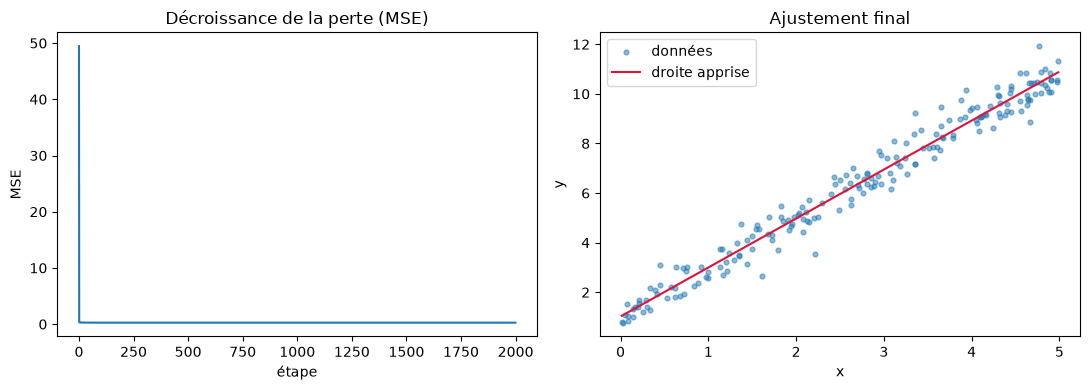

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(historique)
ax1.set(title="Décroissance de la perte (MSE)", xlabel="étape", ylabel="MSE")
ax2.scatter(x_data, y_data, s=12, alpha=0.5, label="données")
xs = np.array([x_data.min(), x_data.max()])
ax2.plot(xs, w_est * xs + b_est, color="crimson", label="droite apprise")
ax2.set(title="Ajustement final", xlabel="x", ylabel="y")
ax2.legend()
plt.tight_layout()
plt.show()

## 4. Raisonnement de Bayes par simulation

On vérifie le « piège du test médical » (module 0, §4.4) : une maladie rare (prévalence 0,1 %), un test
sensible à 99 % mais avec 5 % de faux positifs. La probabilité d'être **réellement** malade après un test
positif est étonnamment faible. On l'estime par simulation, puis on la compare à la valeur analytique.

In [6]:
N = 1_000_000
prevalence, sensibilite, taux_faux_positif = 0.001, 0.99, 0.05

malade = rng.random(N) < prevalence
positif = np.where(
    malade,
    rng.random(N) < sensibilite,        # vrais positifs chez les malades
    rng.random(N) < taux_faux_positif,  # faux positifs chez les sains
)

p_malade_sachant_positif = malade[positif].mean()        # estimation Monte Carlo
# Valeur exacte par le théorème de Bayes
num = sensibilite * prevalence
p_exact = num / (num + taux_faux_positif * (1 - prevalence))

print(f"P(malade | test +) simulée = {p_malade_sachant_positif:.4f}")
print(f"P(malade | test +) exacte  = {p_exact:.4f}")
assert np.isclose(p_malade_sachant_positif, p_exact, atol=0.004)
print("-> moins de 2 % : un test 'à 99 %' ne rend PAS quasi certain d'être malade quand la maladie est rare.")

P(malade | test +) simulée = 0.0198
P(malade | test +) exacte  = 0.0194
-> moins de 2 % : un test 'à 99 %' ne rend PAS quasi certain d'être malade quand la maladie est rare.


## 5. Loi des grands nombres, softmax stable et broadcasting

Trois vérifications express du module 0.

In [7]:
# (a) Loi des grands nombres : la moyenne de lancers de dé converge vers l'espérance 3.5
lancers = rng.integers(1, 7, size=100_000)
print("moyenne empirique de 100 000 dés :", round(lancers.mean(), 4), "(espérance = 3.5)")
assert abs(lancers.mean() - 3.5) < 0.05

# (b) Softmax : la version naïve déborde, la version stable non (module 0, §8.4)
def softmax_naif(z):
    e = np.exp(z)
    return e / e.sum()

def softmax_stable(z):
    z = z - z.max()      # décale sans changer le résultat mathématique
    e = np.exp(z)
    return e / e.sum()

z = np.array([1000.0, 1001.0, 1002.0])
with np.errstate(over="ignore", invalid="ignore"):
    naif = softmax_naif(z)
stable = softmax_stable(z)
print("softmax naïf   :", naif, "(déborde)")
print("softmax stable :", np.round(stable, 4), "somme =", round(stable.sum(), 6))
assert np.isnan(naif).any(), "la version naïve produit des NaN (inf/inf)"
assert np.isclose(stable.sum(), 1.0) and not np.isnan(stable).any()

# (c) Piège broadcasting (n,) vs (n,1) : une soustraction 'innocente' crée une matrice
a = np.arange(3)                     # forme (3,)
piege = a - a.reshape(3, 1)          # (3,) - (3,1) -> (3,3) au lieu d'une erreur !
print("forme inattendue :", piege.shape)
assert piege.shape == (3, 3), "broadcasting silencieux : vérifiez toujours .shape"

# Centrage CORRECT d'une matrice colonne par colonne
M = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
M_centre = M - M.mean(axis=0)        # (3,2) - (2,) -> (3,2), une moyenne par colonne
assert np.allclose(M_centre.mean(axis=0), 0.0)

moyenne empirique de 100 000 dés : 3.5116 (espérance = 3.5)
softmax naïf   : [nan nan nan] (déborde)
softmax stable : [0.09   0.2447 0.6652] somme = 1.0
forme inattendue : (3, 3)


## 6. Exercice guidé — standardisation (z-score) par colonne

Complétez la fonction `standardiser` : pour chaque colonne, soustraire la moyenne et diviser par
l'écart-type (module 1, §4.3). **Critère de réussite** : chaque colonne du résultat doit avoir une
moyenne ≈ 0 et un écart-type ≈ 1.

In [8]:
def standardiser(M):
    # TODO : renvoyer (M - moyenne_par_colonne) / ecart_type_par_colonne
    # Indice : utilisez M.mean(axis=0) et M.std(axis=0)
    raise NotImplementedError("À compléter")

# Décommentez pour tester votre version :
# X_std = standardiser(rng.normal(5, 3, size=(100, 4)))
# assert np.allclose(X_std.mean(axis=0), 0, atol=1e-9)
# assert np.allclose(X_std.std(axis=0), 1, atol=1e-9)

### Solution

In [9]:
def standardiser(M):
    return (M - M.mean(axis=0)) / M.std(axis=0)

X = rng.normal(loc=5.0, scale=3.0, size=(100, 4))
X_std = standardiser(X)
print("moyennes par colonne :", np.round(X_std.mean(axis=0), 6))
print("écarts-types par col. :", np.round(X_std.std(axis=0), 6))
assert np.allclose(X_std.mean(axis=0), 0.0, atol=1e-9)
assert np.allclose(X_std.std(axis=0), 1.0, atol=1e-9)
print("OK : chaque colonne est centrée-réduite.")

moyennes par colonne : [ 0.  0.  0. -0.]
écarts-types par col. : [1. 1. 1. 1.]
OK : chaque colonne est centrée-réduite.


## Récapitulatif

- Le **produit scalaire** relie données et poids ; surveillez toujours les **formes**.
- La **distance** dépend de l'échelle → *scaling* ; le **cosinus** mesure l'angle.
- La **descente de gradient** suit le sens opposé du gradient pour minimiser une perte.
- **Bayes** : un test très sensible reste peu concluant si l'événement est rare.
- Attention aux **NaN/overflow** et au **broadcasting** silencieux.

Suite : [Module 1 — préparation des données](../01_nature_et_preparation_des_donnees/cours_nature_et_preparation_donnees.md).